# By: Raunak Regmi
## Project: Predicting Tesla's Next-Day Return with Linear Regression
**Dataset:** "Tesla Stock Price" from Kaggle (rpaguirre)

### Instructions:
Download the CSV from Kaggle, upload it to your Colab workspace, and run this file from top to bottom.

---



In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [28]:
df = pd.read_csv("Tesla_Data.csv")

print(df.shape)   # how many rows and columns
print(df.head())  # the first 5 rows

(1692, 7)
        Date       Open   High        Low      Close    Volume  Adj Close
0  6/29/2010  19.000000  25.00  17.540001  23.889999  18766300  23.889999
1  6/30/2010  25.790001  30.42  23.299999  23.830000  17187100  23.830000
2   7/1/2010  25.000000  25.92  20.270000  21.959999   8218800  21.959999
3   7/2/2010  23.000000  23.10  18.709999  19.200001   5139800  19.200001
4   7/6/2010  20.000000  20.00  15.830000  16.110001   6866900  16.110001


In [52]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df = df.sort_values("Date")

if "Adj Close" in df.columns:
    df = df.drop(columns=["Adj Close"])

print("Missing value scan counts per attribute:")
print(df.isnull().sum())

Missing value scan counts per attribute:
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Daily_Return     0
Return_Lag1      0
Volatility_5     0
Volume_Change    0
HL_Range         0
Target           0
Year             0
dtype: int64


In [30]:
df["Daily_Return"]  = df["Close"].pct_change()              # today's % change
df["Return_Lag1"]   = df["Daily_Return"].shift(1)           # yesterday's return
df["Volatility_5"]  = df["Daily_Return"].rolling(5).std()   # recent ups and downs
df["Volume_Change"] = df["Volume"].pct_change()             # change in volume
df["HL_Range"]      = (df["High"] - df["Low"]) / df["Close"]  # daily price range


df["Target"] = df["Daily_Return"].shift(-1)

df = df.dropna()

In [31]:
print(df.describe())

                                Date         Open         High          Low  \
count                           1686  1686.000000  1686.000000  1686.000000   
mean   2013-11-09 00:30:44.839857664   132.689413   135.018126   130.247189   
min              2010-07-07 00:00:00    16.139999    16.629999    14.980000   
25%              2012-03-07 06:00:00    30.022500    30.755000    29.314999   
50%              2013-11-07 12:00:00   157.900002   163.104996   154.199997   
75%              2015-07-14 18:00:00   220.592499   224.180000   217.139996   
max              2017-03-16 00:00:00   287.670013   291.420013   280.399994   
std                              NaN    94.232954    95.624705    92.768658   

             Close        Volume  Daily_Return  Return_Lag1  Volatility_5  \
count  1686.000000  1.686000e+03   1686.000000  1686.000000   1686.000000   
mean    132.682562  4.248777e+06      0.002178     0.002068      0.027911   
min      15.800000  1.185000e+05     -0.193274    -0.1932

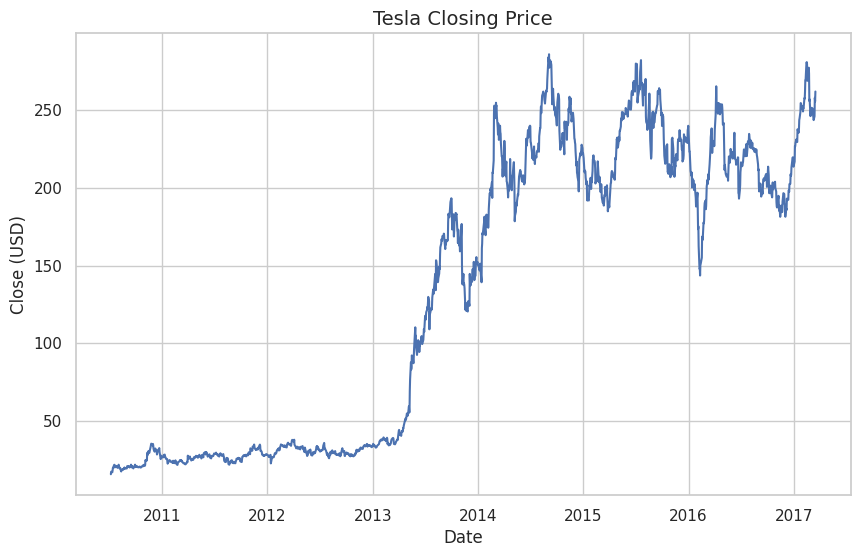

In [36]:
# Closing price over time

plt.plot(df["Date"], df["Close"])
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Close (USD)")
plt.show()



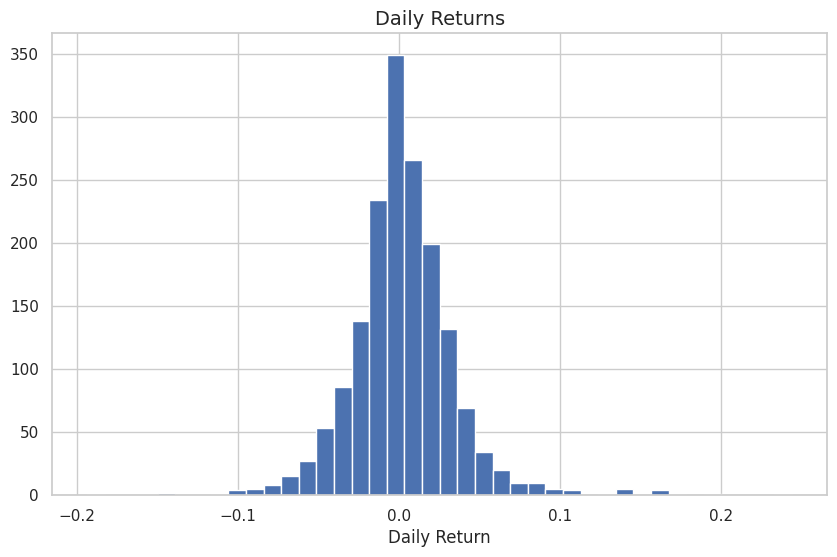

In [37]:
# Histogram of daily returns

plt.hist(df["Daily_Return"], bins=40)
plt.title("Daily Returns")
plt.xlabel("Daily Return")
plt.show()



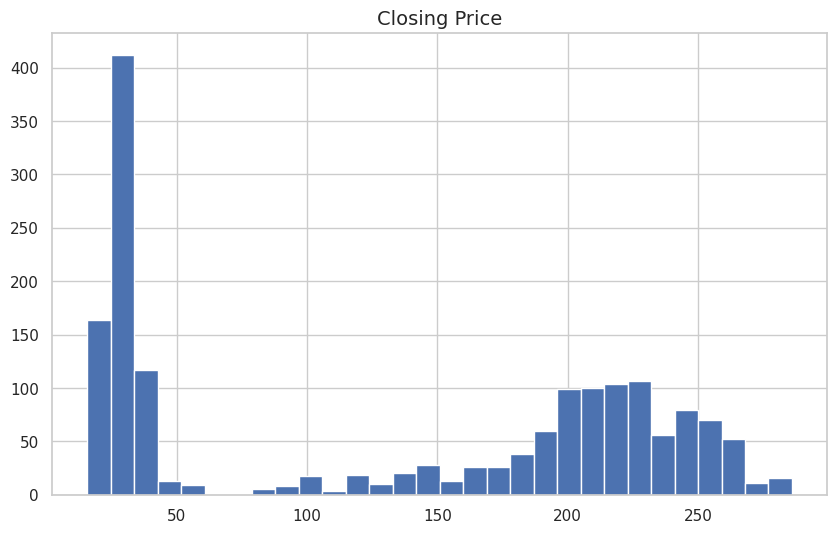

In [38]:
# Histogram of closing price

plt.hist(df["Close"], bins=30)
plt.title("Closing Price")
plt.show()



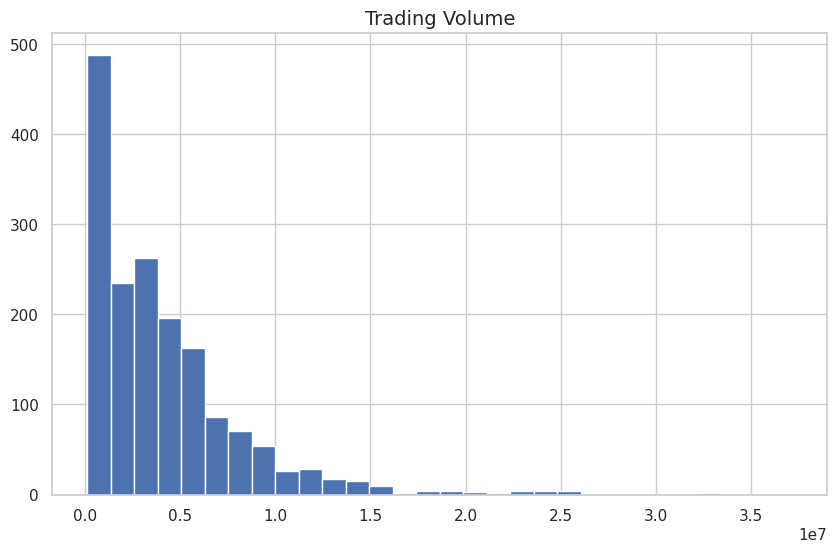

In [39]:
# Histogram of volume

plt.hist(df["Volume"], bins=30)
plt.title("Trading Volume")
plt.show()



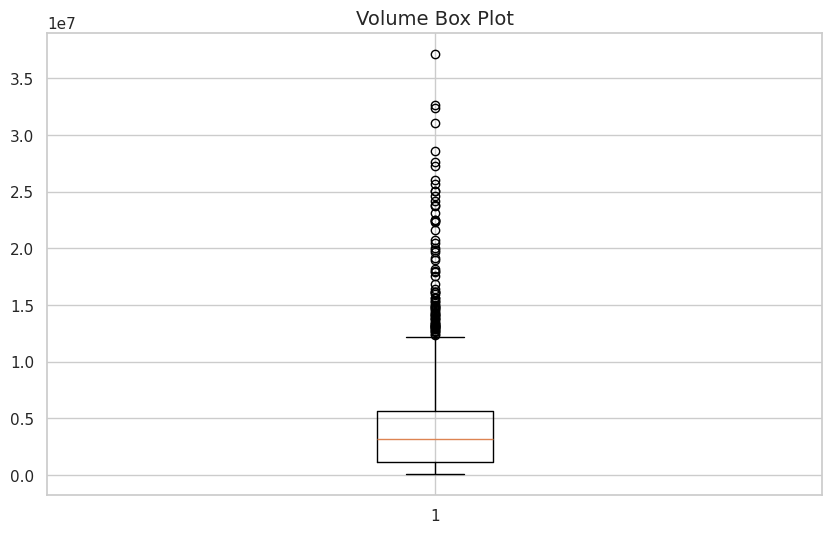

In [40]:
# Box plot of volume (to look for outliers)

plt.boxplot(df["Volume"])
plt.title("Volume Box Plot")
plt.show()



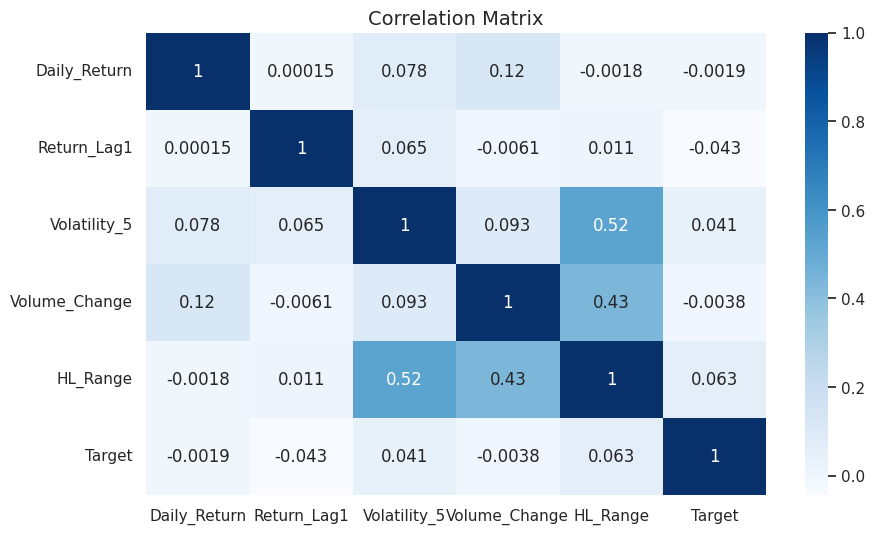

In [41]:

columns = ["Daily_Return", "Return_Lag1", "Volatility_5", "Volume_Change", "HL_Range", "Target"]
sns.heatmap(df[columns].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()



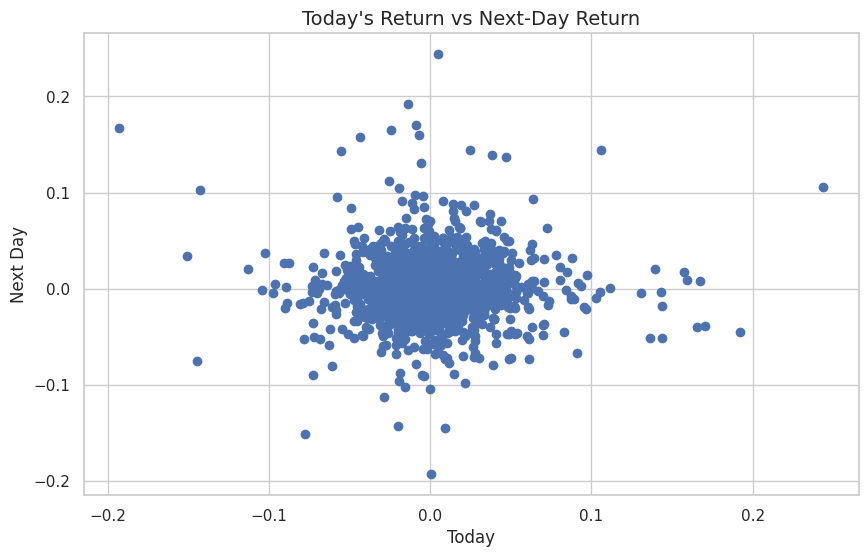

In [42]:
# Today's return vs next day's return

plt.scatter(df["Daily_Return"], df["Target"])
plt.title("Today's Return vs Next-Day Return")
plt.xlabel("Today")
plt.ylabel("Next Day")
plt.show()



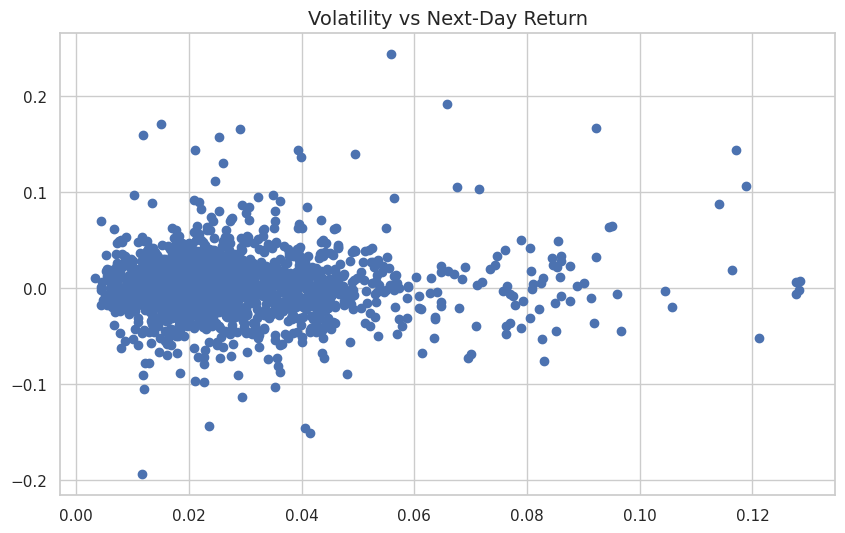

In [43]:
# Volatility vs next day's return
plt.scatter(df["Volatility_5"], df["Target"])
plt.title("Volatility vs Next-Day Return")
plt.show()


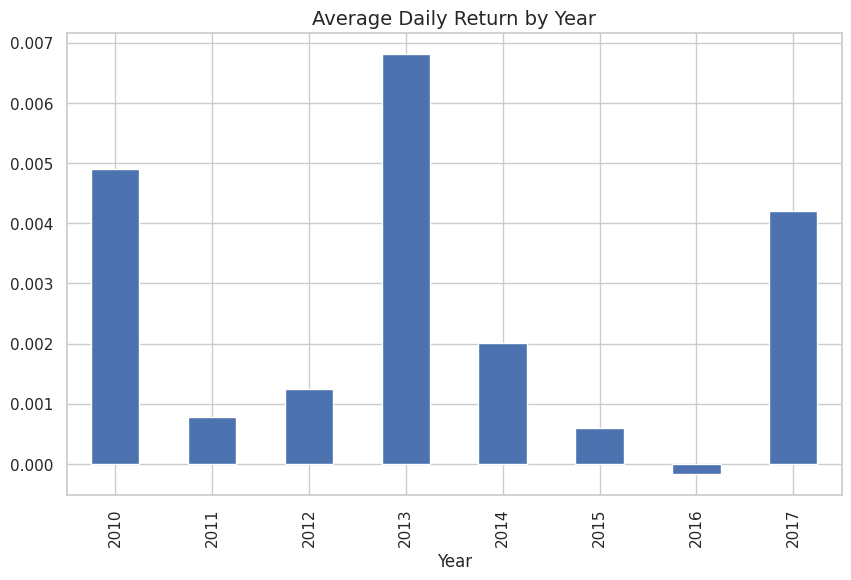

In [44]:

# Average daily return for each year
df["Year"] = df["Date"].dt.year
year_average = df.groupby("Year")["Daily_Return"].mean()
year_average.plot(kind="bar")
plt.title("Average Daily Return by Year")
plt.show()

In [53]:
features = ["Daily_Return", "Return_Lag1", "Volatility_5", "Volume_Change", "HL_Range"]
X = df[features]
y = df["Target"]


# We train on the first 80% of days and test on the last 20%.

split = int(len(X) * 0.8)
X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

R-squared: -0.030574985801865795
RMSE: 0.023878755730465606
MAE: 0.017239115021143423
Coefficients: [-0.00861432 -0.05822307  0.0068584  -0.0016798   0.13564911]
Baseline RMSE: 0.023585605429092403


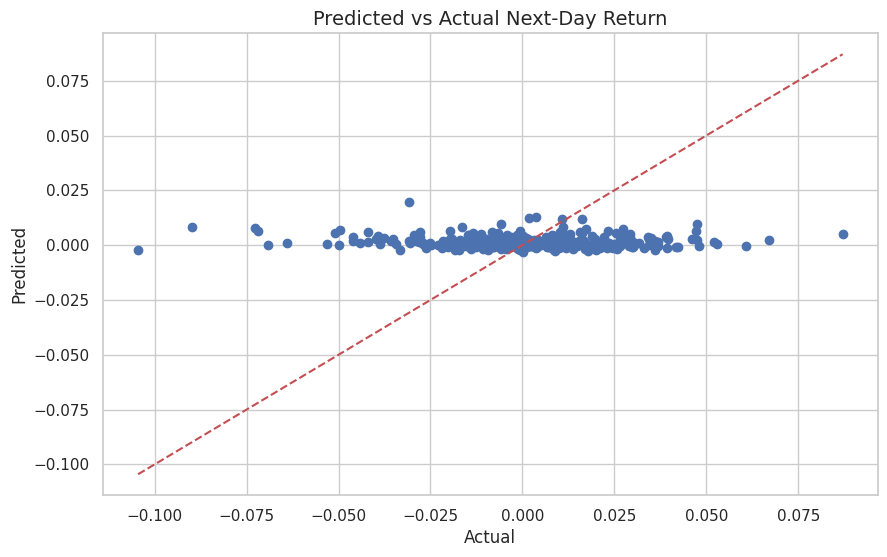

In [46]:
print("R-squared:", r2_score(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("MAE:", mean_absolute_error(y_test, predictions))
print("Coefficients:", model.coef_)

baseline = [y_train.mean()] * len(y_test)
print("Baseline RMSE:", mean_squared_error(y_test, baseline) ** 0.5)

# Predicted vs actual chart

plt.scatter(y_test, predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Predicted vs Actual Next-Day Return")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()